# Lab MQTT — 03. Message Analysis

Loads the file produced by `02_mqtt_collector.py` (a list of records, one MQTT message per
row) and reproduces, on our own dataset, the main analyses of *MQTT in the Wild*:

1. **Payload type** distribution (string / json / numeric / bool / unknown) → paper Fig. 9
2. **QoS** distribution (0 / 1 / 2)
3. % of **retained** messages per broker → paper Fig. 10c
4. **Payload length CDF** → paper Fig. 10a
5. **Topic depth and length CDFs** → paper Fig. 8
6. Observed **throughput** per broker (messages/min)
7. **Top topics** received per broker

In [1]:
import gzip, pickle
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = Path("./outputs")
files = sorted(OUT_DIR.glob("*.gz"))
print("File trovati:", [f.name for f in files])

def load_pkl_gz(path):
    with gzip.open(path, "rb") as fh:
        return pd.DataFrame(pickle.load(fh))

File trovati: ['1.gz', '2.gz', '3.gz', '4.gz', '5.gz', '6.gz']


In [2]:
frames = []
for f in files:
    try:
        d = load_pkl_gz(f)
        d["source"] = f.name
        frames.append(d)
    except EOFError:
        print(f"Skipping corrupted file: {f.name}")

df = pd.concat(frames, ignore_index=True)
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

print("Totale messaggi:", len(df))
print("Per file:\n", df["source"].value_counts())
print("Broker:", df["broker"].unique())
print("Period:", df['datetime'].min(), '→', df['datetime'].max())
df.head()

Totale messaggi: 17391254
Per file:
 source
6.gz    3397944
1.gz    2969635
4.gz    2863190
2.gz    2855591
3.gz    2727574
5.gz    2577320
Name: count, dtype: int64
Broker: ['emqx_cn' 'emqx' 'hivemq' 'mosquitto']
Period: 2026-05-30 14:10:54.122883081 → 2026-06-03 11:51:29.731420755


,timestamp,broker,topic,topic_depth,topic_length,qos,retain,dup,payload_length,payload_type,payload_head,source,datetime
0,1.780150e+09,emqx_cn,gateway/monitor,2,15,0,True,False,128,json,"b'{""memory"":27.2279148'",1.gz,2026-05-30 14:10:54.122883081
1,1.780150e+09,emqx_cn,tasmota/discovery/08D1F9C557F4/config,4,37,0,True,False,914,json,"b'{""ip"":""192.168.1.100'",1.gz,2026-05-30 14:10:54.123028994
2,1.780150e+09,emqx_cn,tasmota/discovery/08D1F9C557F4/sensors,4,38,0,True,False,60,json,"b'{""sn"":{""Time"":""2026-'",1.gz,2026-05-30 14:10:54.123130322
3,1.780150e+09,emqx_cn,tasmota/discovery/08D1F9E547A4/config,4,37,0,True,False,897,json,"b'{""ip"":""192.168.1.27""'",1.gz,2026-05-30 14:10:54.123368263
4,1.780150e+09,emqx_cn,tasmota/discovery/08D1F9E547A4/sensors,4,38,0,True,False,285,json,"b'{""sn"":{""Time"":""2026-'",1.gz,2026-05-30 14:10:54.123697758


## 1. Payload type distribution (paper Fig. 9)

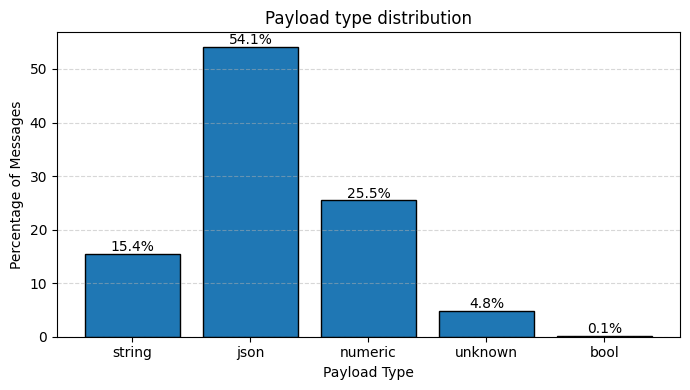

In [4]:
ORDER = ['string', 'json', 'numeric', 'unknown', 'bool']
vc = df['payload_type'].value_counts(normalize=True).reindex(ORDER, fill_value=0) * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(vc.index, vc.values, edgecolor='black')
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha='center')
ax.set_ylabel('Percentage of Messages')
ax.set_xlabel('Payload Type')
ax.set_title('Payload type distribution')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_payload_types.png", dpi=140)
plt.show()

## 2. QoS distribution

**Important:** we subscribe at QoS 2, so the `qos` field of the received message shows the
**publisher's original QoS** (MQTT delivers at the minimum between published and subscribed
QoS, and since we are at 2 the value is not degraded).

qos
0    85.961007
1     6.258841
2     7.780152
Name: proportion, dtype: float64


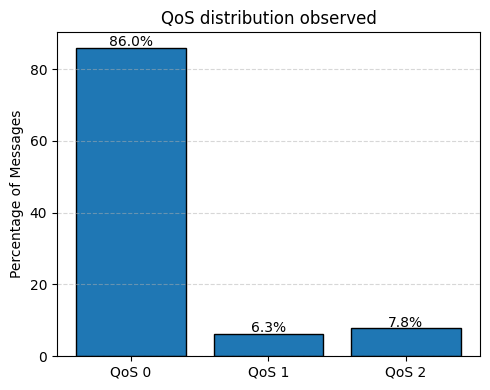

In [5]:
qos_dist = df['qos'].value_counts(normalize=True).sort_index() * 100
print(qos_dist)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar([f'QoS {q}' for q in qos_dist.index], qos_dist.values, edgecolor='black')
for b, v in zip(bars, qos_dist.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha='center')
ax.set_ylabel('Percentage of Messages')
ax.set_title('QoS distribution observed')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_qos.png", dpi=140)
plt.show()

## 3. Retain flag — per broker

broker
hivemq       7.929748
mosquitto    4.085223
emqx         2.725266
emqx_cn      2.551003
Name: retain, dtype: float64


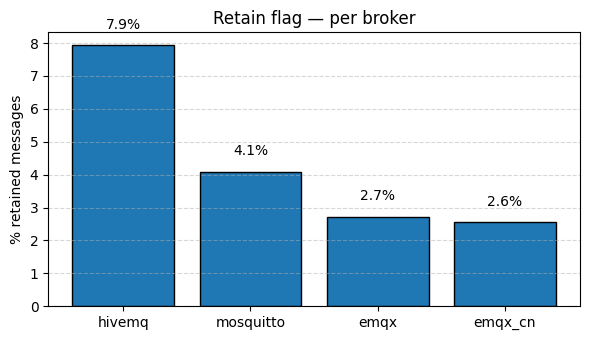

In [6]:
retain_per_broker = df.groupby('broker')['retain'].mean() * 100
retain_per_broker = retain_per_broker.sort_values(ascending=False)
print(retain_per_broker)

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(retain_per_broker.index, retain_per_broker.values, edgecolor='black')
for b, v in zip(bars, retain_per_broker.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha='center')
ax.set_ylabel('% retained messages')
ax.set_title('Retain flag — per broker')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_retain.png", dpi=140)
plt.show()

## 4. Payload length CDF (paper Fig. 10a)

/tmp/ipykernel_825/1072032679.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_825/1072032679.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(OUT_DIR / "fig_payload_length_cdf.png", dpi=140)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


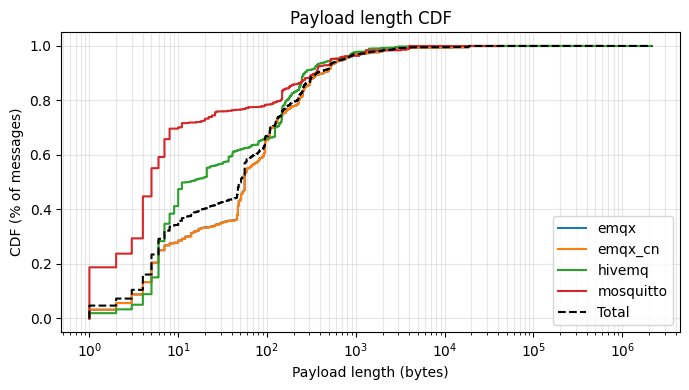

P50 payload length: 51 bytes
P90 payload length: 366 bytes
P99 payload length: 2765 bytes


In [7]:
def cdf(arr):
    arr = np.sort(np.asarray(arr))
    y = np.arange(1, len(arr)+1) / len(arr)
    return arr, y

fig, ax = plt.subplots(figsize=(7, 4))
for name, sub in df.groupby('broker'):
    x, y = cdf(sub['payload_length'].values)
    ax.step(np.maximum(x, 1), y, where='post', label=name)
x, y = cdf(df['payload_length'].values)
ax.step(np.maximum(x, 1), y, where='post', linestyle='--', color='black', label='Total')
ax.set_xscale('log')
ax.set_xlabel('Payload length (bytes)')
ax.set_ylabel('CDF (% of messages)')
ax.set_title('Payload length CDF')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_payload_length_cdf.png", dpi=140)
plt.show()

for q in (0.5, 0.9, 0.99):
    print(f"P{int(q*100)} payload length: {int(np.quantile(df['payload_length'], q))} bytes")

## 5. Topic depth and length CDF (paper Fig. 8)

/tmp/ipykernel_825/4246577541.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_825/4246577541.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(OUT_DIR / "fig_topic_cdf.png", dpi=140)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


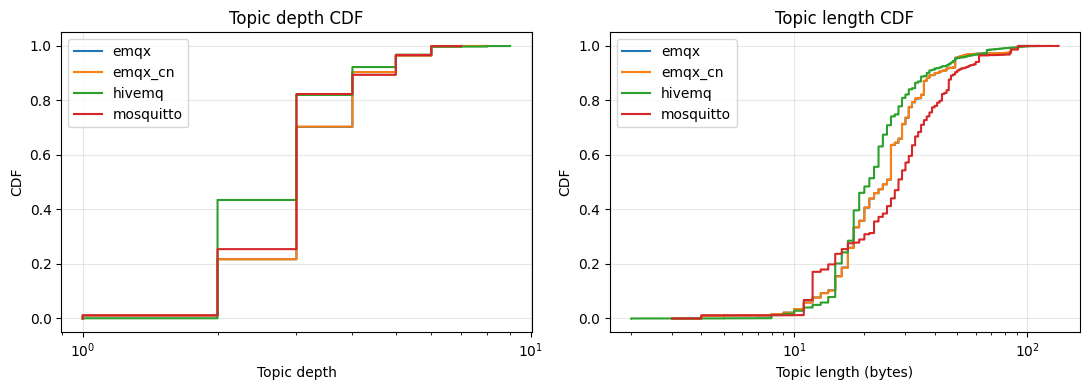

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, sub in df.groupby('broker'):
    x, y = cdf(sub['topic_depth'].values)
    axes[0].step(x, y, where='post', label=name)
    x, y = cdf(sub['topic_length'].values)
    axes[1].step(x, y, where='post', label=name)
axes[0].set_xscale('log'); axes[0].set_xlabel('Topic depth'); axes[0].set_ylabel('CDF')
axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].set_xscale('log'); axes[1].set_xlabel('Topic length (bytes)'); axes[1].set_ylabel('CDF')
axes[1].grid(True, alpha=0.3); axes[1].legend()
axes[0].set_title('Topic depth CDF')
axes[1].set_title('Topic length CDF')
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_topic_cdf.png", dpi=140)
plt.show()

## 6. Throughput per broker (msg/minute)

**First capture**

Messaggi il 2026-05-30: 2969635


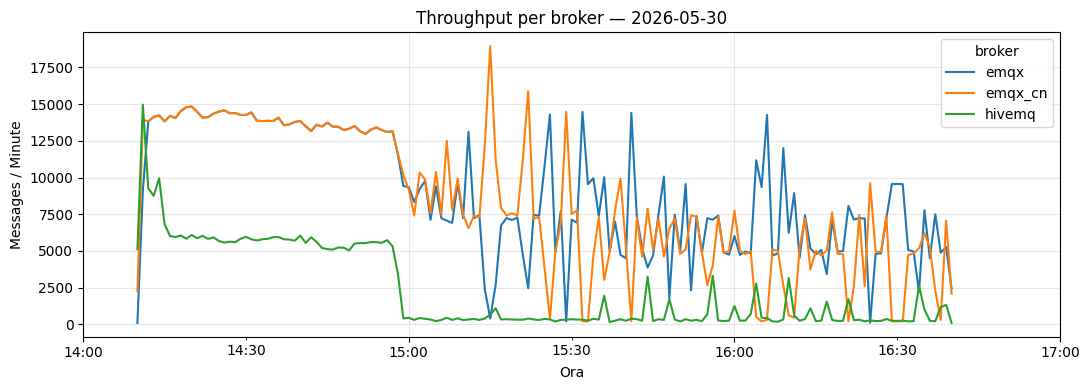

Media msg/min per broker:
broker
emqx       8934.2
emqx_cn    8393.8
hivemq     2338.5
dtype: float64


In [20]:
day = "2026-05-30"

mask = df['datetime'].dt.normalize() == pd.Timestamp(day)
day_df = df[mask].copy()
print(f"Messaggi il {day}:", len(day_df))

day_df['minute'] = day_df['datetime'].dt.floor('min')
rate = day_df.groupby(['minute', 'broker']).size().unstack(fill_value=0)

full_idx = pd.date_range(f"{day} 14:00", f"{day} 17:00", freq='min')
rate = rate.reindex(full_idx)

fig, ax = plt.subplots(figsize=(11, 4))
rate.plot(ax=ax)
ax.set_ylabel('Messages / Minute')
ax.set_xlabel('Ora')
ax.set_title(f'Throughput per broker — {day}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_throughput_{day}.png", dpi=140)
plt.show()

print("Media msg/min per broker:")
print(rate.mean().round(1))

**Second capture**

Messaggi il 2026-05-31: 5583165


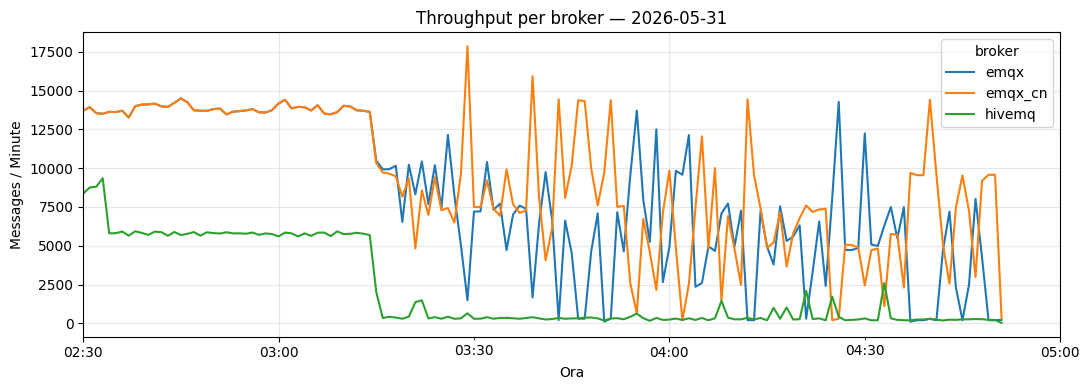

Media msg/min per broker:
broker
emqx       8287.6
emqx_cn    9324.3
hivemq     2207.7
dtype: float64


In [24]:
day = "2026-05-31"

mask = df['datetime'].dt.normalize() == pd.Timestamp(day)
day_df = df[mask].copy()
print(f"Messaggi il {day}:", len(day_df))

day_df['minute'] = day_df['datetime'].dt.floor('min')
rate = day_df.groupby(['minute', 'broker']).size().unstack(fill_value=0)

full_idx = pd.date_range(f"{day} 02:30", f"{day} 05:00", freq='min')
rate = rate.reindex(full_idx)

fig, ax = plt.subplots(figsize=(11, 4))
rate.plot(ax=ax)
ax.set_ylabel('Messages / Minute')
ax.set_xlabel('Ora')
ax.set_title(f'Throughput per broker — {day}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_throughput_{day}.png", dpi=140)
plt.show()

print("Media msg/min per broker:")
print(rate.mean().round(1))

**Third capture**

Messaggi il 2026-05-31: 5583165


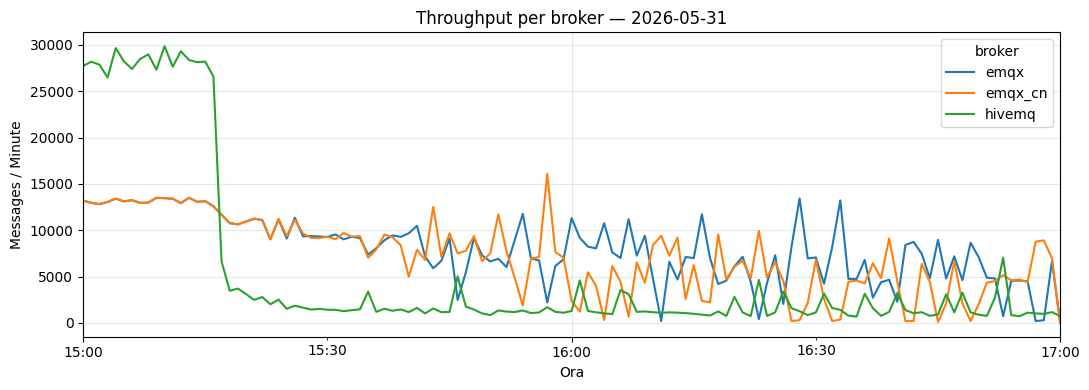

Media msg/min per broker:
broker
emqx       7966.7
emqx_cn    7230.9
hivemq     5430.5
dtype: float64


In [23]:
day = "2026-05-31"

mask = df['datetime'].dt.normalize() == pd.Timestamp(day)
day_df = df[mask].copy()
print(f"Messaggi il {day}:", len(day_df))

day_df['minute'] = day_df['datetime'].dt.floor('min')
rate = day_df.groupby(['minute', 'broker']).size().unstack(fill_value=0)

full_idx = pd.date_range(f"{day} 15:00", f"{day} 17:00", freq='min')
rate = rate.reindex(full_idx)

fig, ax = plt.subplots(figsize=(11, 4))
rate.plot(ax=ax)
ax.set_ylabel('Messages / Minute')
ax.set_xlabel('Ora')
ax.set_title(f'Throughput per broker — {day}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_throughput_{day}.png", dpi=140)
plt.show()

print("Media msg/min per broker:")
print(rate.mean().round(1))

**Fourth capture**

Messaggi il 2026-06-01: 2863190


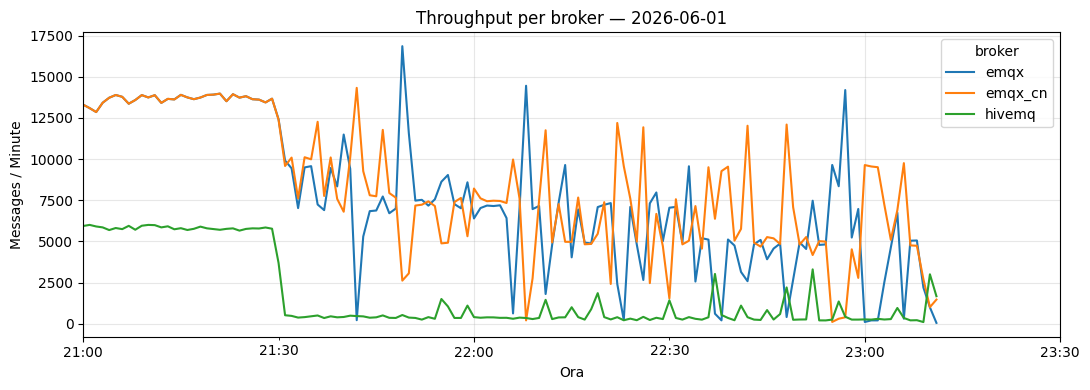

Media msg/min per broker:
broker
emqx       7753.7
emqx_cn    8272.1
hivemq     1776.0
dtype: float64


In [28]:
day = "2026-06-01"

mask = df['datetime'].dt.normalize() == pd.Timestamp(day)
day_df = df[mask].copy()
print(f"Messaggi il {day}:", len(day_df))

day_df['minute'] = day_df['datetime'].dt.floor('min')
rate = day_df.groupby(['minute', 'broker']).size().unstack(fill_value=0)

full_idx = pd.date_range(f"{day} 21:00", f"{day} 23:30", freq='min')
rate = rate.reindex(full_idx)

fig, ax = plt.subplots(figsize=(11, 4))
rate.plot(ax=ax)
ax.set_ylabel('Messages / Minute')
ax.set_xlabel('Ora')
ax.set_title(f'Throughput per broker — {day}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_throughput_{day}.png", dpi=140)
plt.show()

print("Media msg/min per broker:")
print(rate.mean().round(1))

**Fifth capture**

Messaggi il 2026-06-02: 2577320


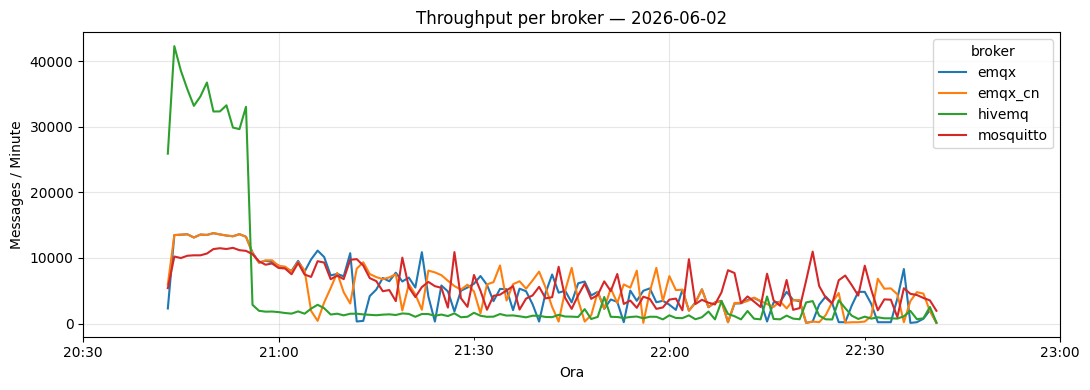

Media msg/min per broker:
broker
emqx         5349.6
emqx_cn      5502.8
hivemq       4895.8
mosquitto    5909.9
dtype: float64


In [30]:
day = "2026-06-02"

mask = df['datetime'].dt.normalize() == pd.Timestamp(day)
day_df = df[mask].copy()
print(f"Messaggi il {day}:", len(day_df))

day_df['minute'] = day_df['datetime'].dt.floor('min')
rate = day_df.groupby(['minute', 'broker']).size().unstack(fill_value=0)

full_idx = pd.date_range(f"{day} 20:30", f"{day} 23:00", freq='min')
rate = rate.reindex(full_idx)

fig, ax = plt.subplots(figsize=(11, 4))
rate.plot(ax=ax)
ax.set_ylabel('Messages / Minute')
ax.set_xlabel('Ora')
ax.set_title(f'Throughput per broker — {day}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_throughput_{day}.png", dpi=140)
plt.show()

print("Media msg/min per broker:")
print(rate.mean().round(1))

**Sixth capture**

Messaggi il 2026-06-03: 3397944


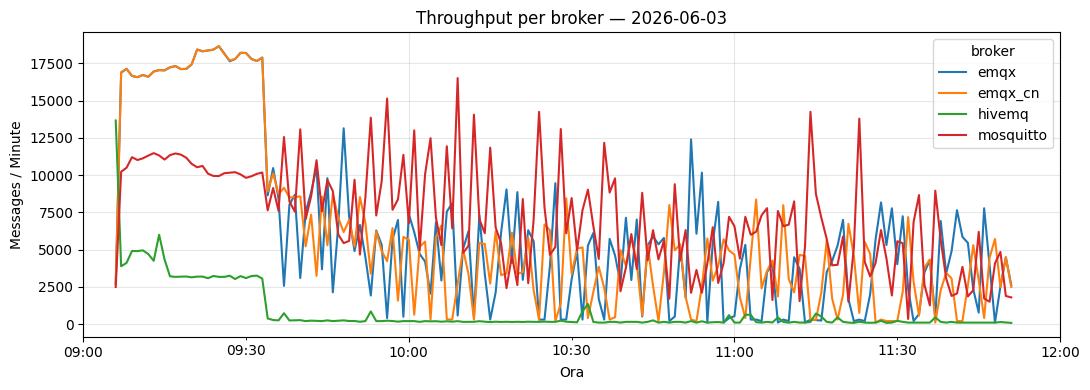

Media msg/min per broker:
broker
emqx         6368.4
emqx_cn      6110.7
hivemq        844.9
mosquitto    7145.6
dtype: float64


In [32]:
day = "2026-06-03"

mask = df['datetime'].dt.normalize() == pd.Timestamp(day)
day_df = df[mask].copy()
print(f"Messaggi il {day}:", len(day_df))

day_df['minute'] = day_df['datetime'].dt.floor('min')
rate = day_df.groupby(['minute', 'broker']).size().unstack(fill_value=0)

full_idx = pd.date_range(f"{day} 09:00", f"{day} 12:00", freq='min')
rate = rate.reindex(full_idx)

fig, ax = plt.subplots(figsize=(11, 4))
rate.plot(ax=ax)
ax.set_ylabel('Messages / Minute')
ax.set_xlabel('Ora')
ax.set_title(f'Throughput per broker — {day}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / f"fig_throughput_{day}.png", dpi=140)
plt.show()

print("Media msg/min per broker:")
print(rate.mean().round(1))

**All captures**

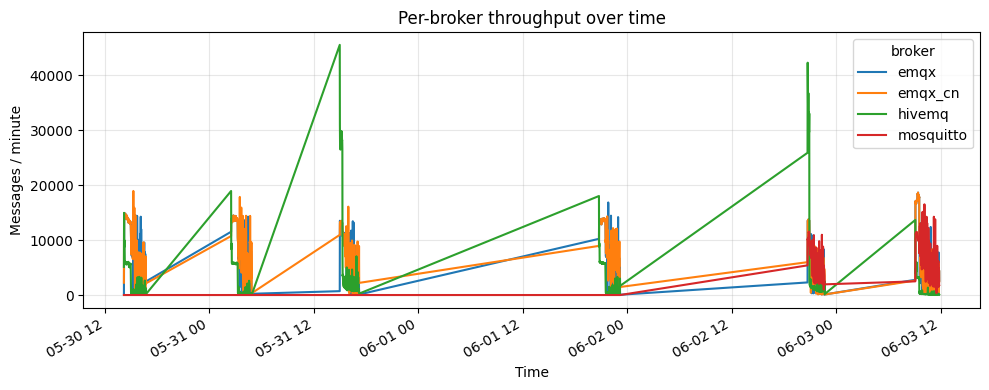

Mean msg/min per broker:
broker
emqx         7505.3
emqx_cn      7588.5
hivemq       2910.6
mosquitto    2194.5
dtype: float64


In [33]:
df['minute'] = df['datetime'].dt.floor('min')
rate = df.groupby(['minute', 'broker']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
rate.plot(ax=ax)
ax.set_ylabel('Messages / minute')
ax.set_xlabel('Time')
ax.set_title('Per-broker throughput over time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_throughput.png", dpi=140)
plt.show()

print("Mean msg/min per broker:")
print(rate.mean().round(1))

## 7. Top topics per broker

In [10]:
for name, sub in df.groupby('broker'):
    print(f"\n=== {name} — top 10 topics ===")
    print(sub['topic'].value_counts().head(10))


=== emqx — top 10 topics ===
topic
tele/tasmota_EB7D9F/SENSOR             500431
water_tank/status                      284626
stat/tasmota_7B7552/RESULT             151121
hoope/users/status                     116534
test/room/temperature                   89957
test/room/humidity                      87186
esp32/sensor/data                       78485
tele/v13.0/1213                         61707
stat/ahoydtuljkbbkjcyjkjj56/STATUS8     59979
filament/status                         59686
Name: count, dtype: int64

=== emqx_cn — top 10 topics ===
topic
tele/tasmota_EB7D9F/SENSOR             510721
water_tank/status                      289595
stat/tasmota_7B7552/RESULT             153690
hoope/users/status                     123455
test/room/temperature                   91359
test/room/humidity                      88549
esp32/sensor/data                       80123
tele/v13.0/1213                         62700
filament/status                         61573
stat/ahoydtuljkbbkjcyjkjj

## 8. Summary table for the presentation

In [11]:
summary = df.groupby('broker').agg(
    n_messages       = ('topic', 'size'),
    n_unique_topics  = ('topic', 'nunique'),
    pct_retained     = ('retain', lambda s: 100*s.mean()),
    pct_qos0         = ('qos', lambda s: 100*(s == 0).mean()),
    pct_qos1         = ('qos', lambda s: 100*(s == 1).mean()),
    pct_qos2         = ('qos', lambda s: 100*(s == 2).mean()),
    median_payload_B = ('payload_length', 'median'),
    median_topic_dep = ('topic_depth', 'median'),
).round(2)
summary.to_csv(OUT_DIR / "per_broker_summary.csv")
summary

,n_messages,n_unique_topics,pct_retained,pct_qos0,pct_qos1,pct_qos2,median_payload_B,median_topic_dep
broker,,,,,,,,
emqx,6462049,5627,2.73,89.44,4.96,5.60,56.0,3.0
emqx_cn,6533704,5723,2.55,89.62,4.86,5.51,56.0,3.0
hivemq,2506057,33671,7.93,58.62,17.61,23.77,13.0,3.0
mosquitto,1889444,2560,4.09,97.68,0.47,1.85,5.0,3.0
